# Run-to-run analysis — `2026_01_article.pdf`

Loads the nine `*_exeN.profile.json` files (exe2 → exe10) for the paper at `data/pdf_original_cache/2026_01_article.pdf` and compares them side-by-side.

**Section 1 — Load & compare executions**: reads every profile, builds a per-execution summary table (counts of methodology steps, datasets, figures, tables, hyperparameters), and stores the raw `PaperProfile` dicts in a dict keyed by `exeN` for downstream analysis.

exe1 is intentionally excluded.

## 1. Load and compare executions

In [21]:
import json
import re
from pathlib import Path

import pandas as pd

PAPER_STEM = "2026_01_article"
CACHE = Path("data/pdf_original_cache")
EXCLUDE = {0}

pattern = re.compile(rf"{re.escape(PAPER_STEM)}_exe(\d+)\.profile\.json$")
profiles: dict[str, dict] = {}
for path in sorted(CACHE.glob(f"{PAPER_STEM}_exe*.profile.json")):
    m = pattern.match(path.name)
    if not m:
        continue
    n = int(m.group(1))
    if n in EXCLUDE:
        continue
    profiles[f"exe{n}"] = json.loads(path.read_text())

# Keep insertion order numeric: exe2, exe3, ..., exe10
profiles = dict(sorted(profiles.items(), key=lambda kv: int(kv[0][3:])))
print(f"Loaded {len(profiles)} executions: {list(profiles)}")

Loaded 12 executions: ['exe1', 'exe2', 'exe3', 'exe4', 'exe5', 'exe6', 'exe7', 'exe8', 'exe9', 'exe10', 'exe11', 'exe12']


In [22]:
rows = []
for exe, prof in profiles.items():
    rows.append({
        "execution": exe,
        "model": prof.get("extraction_model", ""),
        "title": prof.get("title", ""),
        "n_authors": len(prof.get("authors", [])),
        "n_methodology_steps": len(prof.get("methodology_steps", [])),
        "n_datasets": len(prof.get("datasets", [])),
        "n_figures": len(prof.get("figures_to_reproduce", [])),
        "n_tables": len(prof.get("tables_to_reproduce", [])),
        "n_hyperparameters": len(prof.get("hyperparameters", [])),
        "n_repo_links": len(prof.get("repository_links", [])),
        "n_supp_materials": len(prof.get("supplementary_materials", [])),
        "n_software_versions": len(prof.get("stated_software_versions", {})),
        "hardware_requirements": prof.get("hardware_requirements") or "",
    })

summary = pd.DataFrame(rows).set_index("execution")
summary

,model,title,n_authors,n_methodology_steps,n_datasets,n_figures,n_tables,n_hyperparameters,n_repo_links,n_supp_materials,n_software_versions,hardware_requirements
execution,,,,,,,,,,,,
exe1,,LEARNING WITH NOISY LABELS REVISITED: A STUDY ...,6,7,12,6,2,22,6,1,0,"GPU cluster (500 GPUs of all kinds, mainly use..."
exe2,gemini-3-flash-preview,LEARNING WITH NOISY LABELS REVISITED: A STUDY ...,6,12,12,6,2,13,6,1,0,"GPU cluster (500 GPUs of all kinds, mainly use..."
exe3,gemini-3-flash-preview,LEARNING WITH NOISY LABELS REVISITED: A STUDY ...,6,12,12,4,3,13,2,1,0,"GPU cluster (500 GPUs of all kinds, mainly use..."
exe4,gemini-3-flash-preview,LEARNING WITH NOISY LABELS REVISITED: A STUDY ...,6,9,12,13,9,23,6,5,0,"GPU cluster (500 GPUs of all kinds, mainly use..."
exe5,gemini-3-flash-preview,LEARNING WITH NOISY LABELS REVISITED: A STUDY ...,6,8,12,4,3,13,2,1,0,"GPU cluster (500 GPUs of all kinds, mainly use..."
exe6,gemini-3-flash-preview,LEARNING WITH NOISY LABELS REVISITED: A STUDY ...,6,8,12,6,2,13,6,1,0,"GPU cluster (500 GPUs of all kinds, mainly use..."
exe7,gemini-3-flash-preview,LEARNING WITH NOISY LABELS REVISITED: A STUDY ...,6,12,12,6,2,22,2,1,0,"GPU cluster (500 GPUs of all kinds, mainly use..."
exe8,gemini-3-flash-preview,LEARNING WITH NOISY LABELS REVISITED: A STUDY ...,6,9,14,6,2,23,6,5,0,"GPU cluster (500 GPUs of all kinds, mainly use..."
exe9,gemini-3-flash-preview,LEARNING WITH NOISY LABELS REVISITED: A STUDY ...,6,9,12,6,2,23,6,1,0,"GPU cluster (500 GPUs of all kinds, mainly use..."


In [23]:
count_cols = [c for c in summary.columns if c.startswith("n_")]
stats = summary[count_cols].agg(["min", "max", "mean", "std"]).T
stats["range"] = stats["max"] - stats["min"]
stats.round(2)

,min,max,mean,std,range
n_authors,6.0,6.0,6.00,0.00,0.0
n_methodology_steps,7.0,12.0,9.58,1.88,5.0
n_datasets,12.0,14.0,12.17,0.58,2.0
n_figures,4.0,13.0,6.25,2.26,9.0
n_tables,2.0,9.0,2.75,2.01,7.0
n_hyperparameters,13.0,23.0,18.58,4.94,10.0
n_repo_links,2.0,6.0,5.00,1.81,4.0
n_supp_materials,1.0,5.0,1.67,1.56,4.0
n_software_versions,0.0,0.0,0.00,0.00,0.0


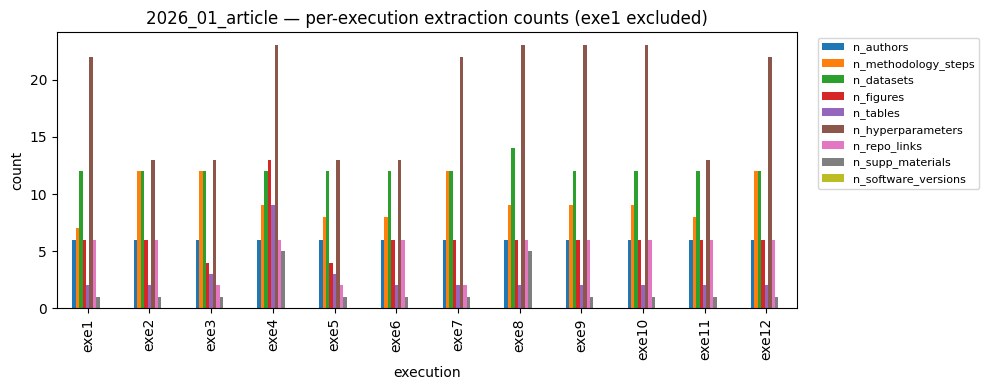

In [24]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))
summary[count_cols].plot(kind="bar", ax=ax)
ax.set_ylabel("count")
ax.set_title(f"{PAPER_STEM} — per-execution extraction counts (exe1 excluded)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

In [5]:
# Sanity check: are title/authors/model identical across executions?
for field in ["title", "authors", "extraction_model", "repository_links"]:
    values = {exe: json.dumps(p.get(field), sort_keys=True) for exe, p in profiles.items()}
    unique = set(values.values())
    print(f"{field}: {len(unique)} unique value(s) across {len(values)} executions")
    if len(unique) > 1:
        for exe, v in values.items():
            print(f"  {exe}: {v[:120]}")

title: 1 unique value(s) across 12 executions
authors: 1 unique value(s) across 12 executions
extraction_model: 2 unique value(s) across 12 executions
  exe1: null
  exe2: "gemini-3-flash-preview"
  exe3: "gemini-3-flash-preview"
  exe4: "gemini-3-flash-preview"
  exe5: "gemini-3-flash-preview"
  exe6: "gemini-3-flash-preview"
  exe7: "gemini-3-flash-preview"
  exe8: "gemini-3-flash-preview"
  exe9: "gemini-3-flash-preview"
  exe10: "gemini-3-flash-preview"
  exe11: "gemini-3-flash-preview"
  exe12: "gemini-3-flash-preview"
repository_links: 3 unique value(s) across 12 executions
  exe1: ["http://noisylabels.com (\"The corresponding datasets and the leaderboard are available at http://noisylabels.com.\")",
  exe2: ["http://noisylabels.com (\"The corresponding datasets and the leaderboard are available at http://noisylabels.com.\")",
  exe3: ["http://noisylabels.com (\"The corresponding datasets and the leaderboard are available at http://noisylabels.com.\")",
  exe4: ["http://noisylabe

In [6]:
# How stable are dataset names across executions?
dataset_sets = {exe: {d["name"] for d in p.get("datasets", [])} for exe, p in profiles.items()}
all_names = set().union(*dataset_sets.values())
presence = pd.DataFrame(
    {exe: [name in names for name in sorted(all_names)] for exe, names in dataset_sets.items()},
    index=sorted(all_names),
).astype(int)
presence["n_runs"] = presence.sum(axis=1)
presence = presence.sort_values("n_runs", ascending=False)
presence

,exe1,exe2,exe3,exe4,exe5,exe6,exe7,exe8,exe9,exe10,exe11,exe12,n_runs
Animal-10N,1,1,1,1,1,1,1,1,1,1,1,1,12
CIFAR-10,1,1,1,1,1,1,1,1,1,1,1,1,12
CIFAR-100,1,1,1,1,1,1,1,1,1,1,1,1,12
CIFAR-10N,1,1,1,1,1,1,1,1,1,1,1,1,12
CIFAR-100N,1,1,1,1,1,1,1,1,1,1,1,1,12
Clothing1M,1,1,1,1,1,1,1,1,1,1,1,1,12
Food-101,1,1,1,1,1,1,1,1,1,1,1,1,12
Red Stanford Cars,1,1,1,1,1,1,1,1,1,1,1,1,12
WebVision,1,1,1,1,1,1,1,1,1,1,1,1,12
Red Mini-ImageNet,1,1,1,1,1,1,1,1,1,1,1,1,12


In [7]:
# Hyperparameter name stability across executions.
hp_sets = {exe: {h["name"] for h in p.get("hyperparameters", [])} for exe, p in profiles.items()}
all_hp = set().union(*hp_sets.values())
hp_presence = pd.DataFrame(
    {exe: [name in names for name in sorted(all_hp)] for exe, names in hp_sets.items()},
    index=sorted(all_hp),
).astype(int)
hp_presence["n_runs"] = hp_presence.sum(axis=1)
hp_presence = hp_presence.sort_values("n_runs", ascending=False)
hp_presence.head(30)

,exe1,exe2,exe3,exe4,exe5,exe6,exe7,exe8,exe9,exe10,exe11,exe12,n_runs
confidence threshold (eta),1,1,1,1,1,1,1,1,1,1,1,1,12
initial learning rate,1,1,1,1,1,1,1,1,1,1,1,1,12
learning rate decay,1,1,1,1,1,1,1,1,1,1,1,1,12
optimizer,1,1,1,1,1,1,1,1,1,1,1,1,12
number of epochs,1,1,1,1,1,1,1,1,1,1,1,1,12
number of runs,1,1,1,1,1,1,1,1,1,1,1,1,12
momentum,1,1,1,1,1,1,1,1,1,1,1,1,12
mini-batch size,1,1,1,1,1,1,1,1,1,1,1,1,12
significance level (alpha),1,1,1,1,1,1,1,1,1,1,1,1,12
weight decay,1,1,1,1,1,1,1,1,1,1,1,1,12


## 2. Graph-theoretic analysis of methodology steps

Each execution's `methodology_steps` is converted into a directed graph:

- **Node** = one methodology step (keyed by its `order`).
- **Edge** `i → j` = step `i`'s `expected_outputs` contains a label that also appears in step `j`'s `data_inputs` (case-insensitive, whitespace-normalised). The exact label match is what the updated `PROMPT_METHODOLOGY` in `gemini_rag.py` is supposed to enforce, so this graph is a direct probe of label-consistency compliance.

Then for each execution we compute the metrics below (all derived only from the methodology section, independently of the step count or text length):

| metric | what it tells us |
|---|---|
| `n_nodes`, `n_edges` | raw size of the methodology pipeline |
| `density` | `E / (V·(V−1))` — how interconnected the steps are |
| `n_isolated` | steps with degree 0 (fully disconnected — reproducibility red flag) |
| `n_sources` | in-degree-0 nodes (expected: the paper's real inputs) |
| `n_sinks` | out-degree-0 nodes (expected: the paper's real outputs) |
| `n_weakly_connected_components` | >1 means the methodology splits into disconnected sub-pipelines |
| `is_dag` | methodologies should be acyclic; cycles usually = label-reuse errors |
| `longest_path_len` | pipeline depth (only if DAG) |
| `topo_matches_declared_order` | does a topological sort of the data-flow agree with the paper's stated step numbering? |
| `label_overlap_ratio` | fraction of `expected_outputs` strings that reappear verbatim in some downstream `data_inputs` — low = label drift |
| `n_dangling_inputs` | non-source steps whose `data_inputs` aren't produced by any upstream step |
| `n_deadend_outputs` | non-sink steps whose `expected_outputs` aren't consumed by any downstream step |
| `avg_betweenness` | mean betweenness centrality — higher = more bottleneck-heavy pipeline |
| `max_betweenness` | the single most load-bearing step |

In [8]:
import networkx as nx


def _norm(label: str) -> str:
    return " ".join(label.lower().split())


def methodology_graph(steps: list[dict]) -> nx.DiGraph:
    """Build a directed graph from a PaperProfile.methodology_steps list.

    Edge i -> j if any label in steps[i].expected_outputs matches any label
    in steps[j].data_inputs (normalised: lowercased, whitespace-collapsed).
    """
    g = nx.DiGraph()
    for s in steps:
        g.add_node(
            s["order"],
            description=s.get("description", ""),
            data_inputs=[_norm(x) for x in s.get("data_inputs", [])],
            expected_outputs=[_norm(x) for x in s.get("expected_outputs", [])],
        )
    nodes = list(g.nodes(data=True))
    for i, (oi, di) in enumerate(nodes):
        outs_i = set(di["expected_outputs"])
        if not outs_i:
            continue
        for oj, dj in nodes:
            if oj == oi:
                continue
            ins_j = set(dj["data_inputs"])
            shared = outs_i & ins_j
            if shared:
                g.add_edge(oi, oj, labels=sorted(shared))
    return g


def graph_metrics(g: nx.DiGraph, steps: list[dict]) -> dict:
    n = g.number_of_nodes()
    m = g.number_of_edges()
    isolated = [v for v in g.nodes if g.in_degree(v) == 0 and g.out_degree(v) == 0]
    sources = [v for v in g.nodes if g.in_degree(v) == 0 and g.out_degree(v) > 0]
    sinks = [v for v in g.nodes if g.out_degree(v) == 0 and g.in_degree(v) > 0]
    wccs = list(nx.weakly_connected_components(g))
    is_dag = nx.is_directed_acyclic_graph(g)

    longest_path_len = None
    topo_matches = None
    if is_dag and n:
        longest_path_len = nx.dag_longest_path_length(g)
        try:
            topo = list(nx.topological_sort(g))
        except nx.NetworkXUnfeasible:
            topo = []
        declared = sorted(g.nodes)  # orders 1..N
        topo_matches = topo == declared

    # Label overlap ratio: fraction of expected_outputs across all steps that
    # re-appear verbatim in some (any) step's data_inputs.
    all_inputs: set[str] = set()
    for _, data in g.nodes(data=True):
        all_inputs.update(data["data_inputs"])
    total_outputs = 0
    matched_outputs = 0
    for _, data in g.nodes(data=True):
        for lbl in data["expected_outputs"]:
            total_outputs += 1
            if lbl in all_inputs:
                matched_outputs += 1
    overlap_ratio = matched_outputs / total_outputs if total_outputs else 0.0

    # Dangling inputs: non-first step with inputs never produced anywhere upstream.
    all_outputs: set[str] = set()
    for _, data in g.nodes(data=True):
        all_outputs.update(data["expected_outputs"])
    dangling = 0
    for v, data in g.nodes(data=True):
        if g.in_degree(v) == 0 and v != min(g.nodes):
            # node never consumes any produced label
            if not (set(data["data_inputs"]) & all_outputs):
                dangling += 1
    # Dead-end outputs: non-last step with outputs never consumed downstream.
    deadend = 0
    for v, data in g.nodes(data=True):
        if g.out_degree(v) == 0 and v != max(g.nodes):
            if not (set(data["expected_outputs"]) & all_inputs):
                deadend += 1

    # Betweenness centrality (bottleneck detection).
    if n >= 3:
        btw = nx.betweenness_centrality(g)
        avg_btw = sum(btw.values()) / n
        max_btw = max(btw.values())
    else:
        avg_btw = 0.0
        max_btw = 0.0

    density = nx.density(g) if n > 1 else 0.0

    return {
        "n_nodes": n,
        "n_edges": m,
        "density": round(density, 3),
        "n_isolated": len(isolated),
        "n_sources": len(sources),
        "n_sinks": len(sinks),
        "n_weakly_connected_components": len(wccs),
        "is_dag": is_dag,
        "longest_path_len": longest_path_len,
        "topo_matches_declared_order": topo_matches,
        "label_overlap_ratio": round(overlap_ratio, 3),
        "n_dangling_inputs": dangling,
        "n_deadend_outputs": deadend,
        "avg_betweenness": round(avg_btw, 3),
        "max_betweenness": round(max_btw, 3),
    }


graphs: dict[str, nx.DiGraph] = {}
metrics_rows = []
for exe, prof in profiles.items():
    steps = prof.get("methodology_steps", [])
    g = methodology_graph(steps)
    graphs[exe] = g
    metrics_rows.append({"execution": exe, **graph_metrics(g, steps)})

metrics_df = pd.DataFrame(metrics_rows).set_index("execution")
metrics_df

,n_nodes,n_edges,density,n_isolated,n_sources,n_sinks,n_weakly_connected_components,is_dag,longest_path_len,topo_matches_declared_order,label_overlap_ratio,n_dangling_inputs,n_deadend_outputs,avg_betweenness,max_betweenness
execution,,,,,,,,,,,,,,,
exe1,7,1,0.024,5,1,1,6,True,1,False,0.143,5,5,0.000,0.000
exe2,12,11,0.083,0,4,3,1,True,4,False,0.765,3,2,0.017,0.073
exe3,12,11,0.083,0,4,3,1,True,4,False,0.765,3,2,0.017,0.073
exe4,9,8,0.111,0,3,2,1,True,3,False,0.857,2,1,0.022,0.071
exe5,8,8,0.143,0,2,3,1,True,3,False,0.556,1,2,0.036,0.143
exe6,8,8,0.143,0,2,3,1,True,3,False,0.556,1,2,0.036,0.143
exe7,12,11,0.083,0,4,3,1,True,4,False,0.765,3,2,0.017,0.073
exe8,9,8,0.111,0,2,3,1,True,3,False,0.800,1,2,0.028,0.107
exe9,9,8,0.111,0,3,2,1,True,3,False,0.857,2,1,0.022,0.071


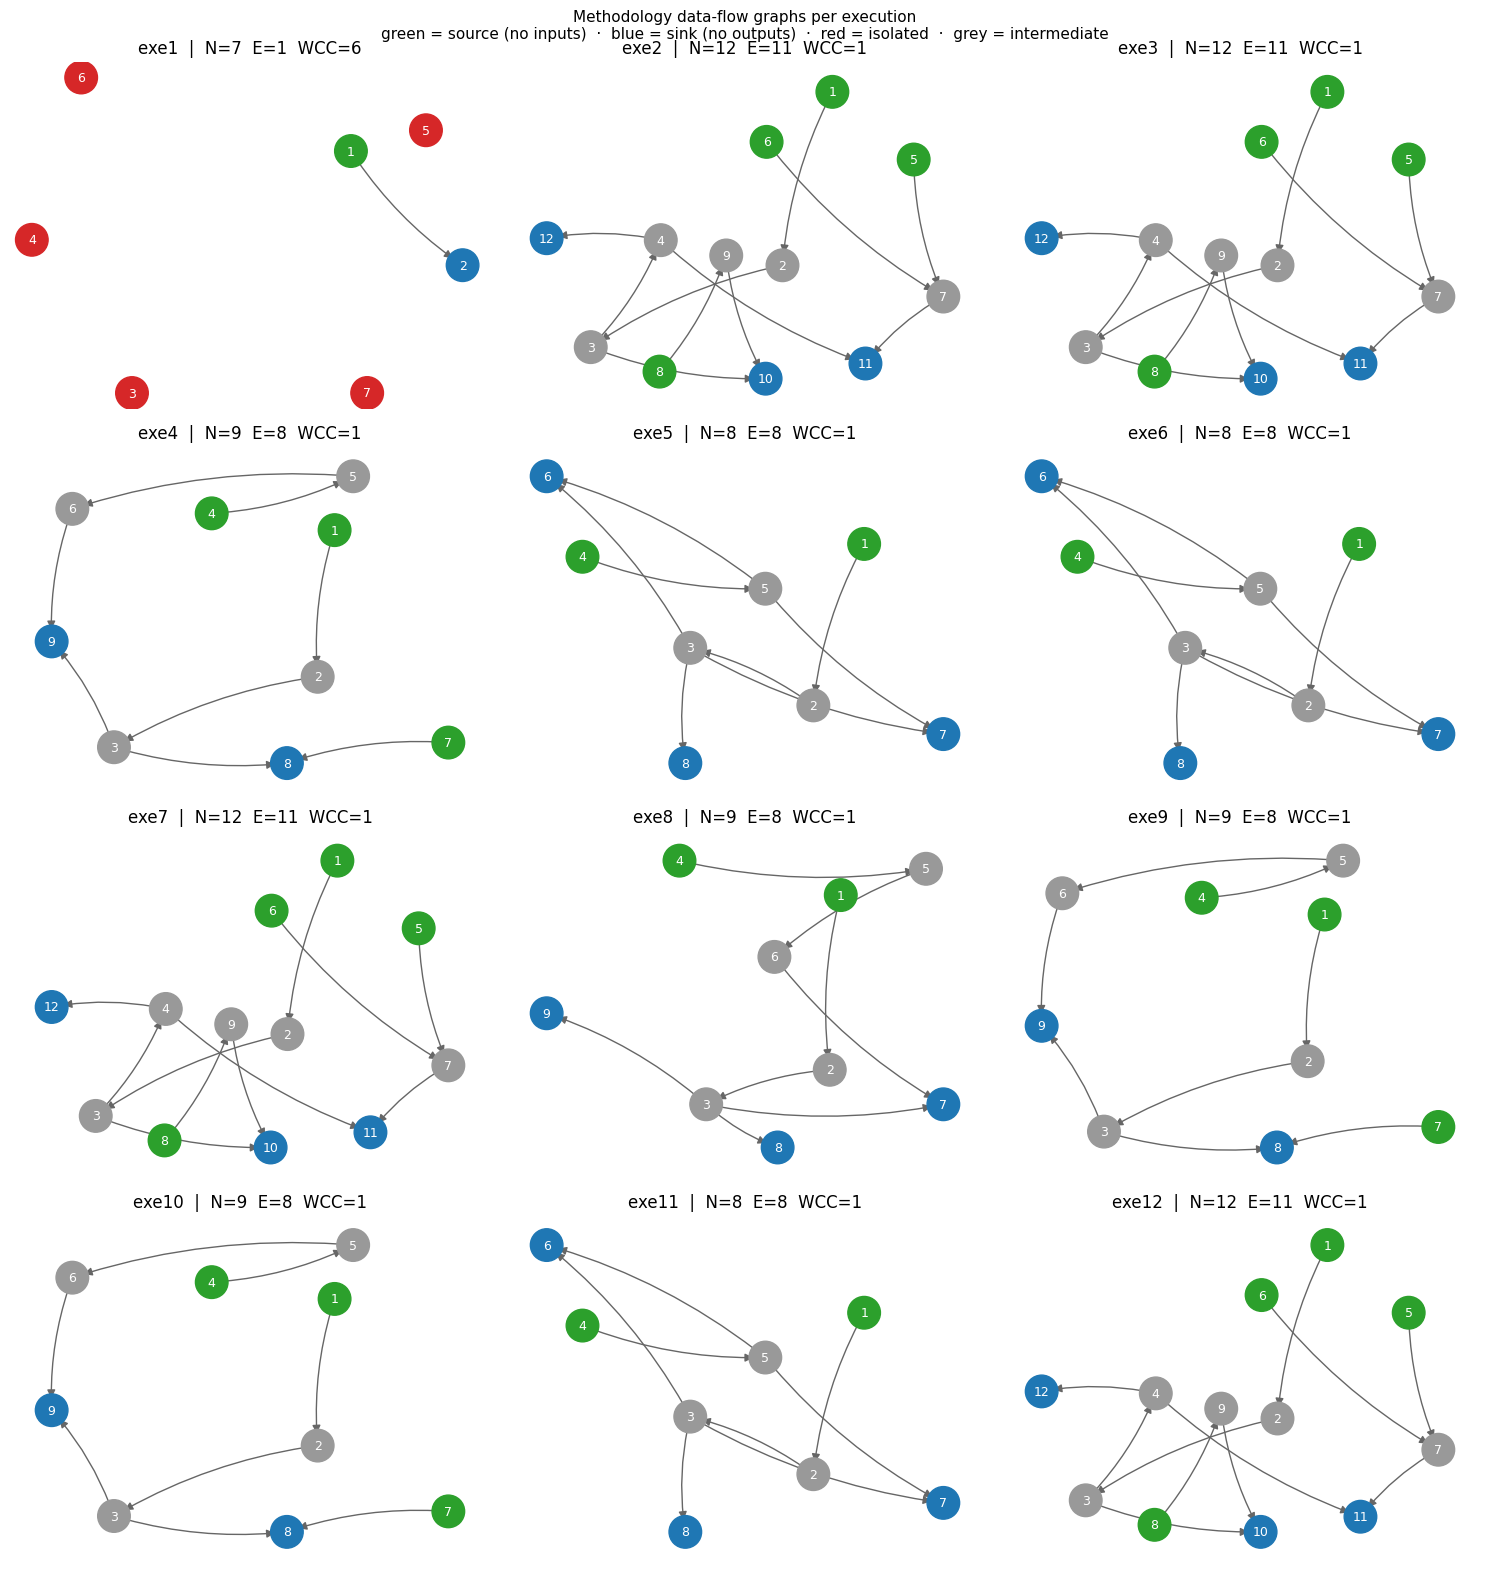

In [9]:
import math

n = len(graphs)
cols = 3
rows = math.ceil(n / cols)
fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
axes = axes.flatten()

for ax, (exe, g) in zip(axes, graphs.items()):
    if g.number_of_nodes() == 0:
        ax.set_title(f"{exe} (empty)")
        ax.axis("off")
        continue
    try:
        pos = nx.spring_layout(g, seed=42, k=1.2)
    except Exception:
        pos = nx.circular_layout(g)

    node_colors = []
    for v in g.nodes:
        if g.in_degree(v) == 0 and g.out_degree(v) == 0:
            node_colors.append("#d62728")   # isolated (red)
        elif g.in_degree(v) == 0:
            node_colors.append("#2ca02c")   # source (green)
        elif g.out_degree(v) == 0:
            node_colors.append("#1f77b4")   # sink (blue)
        else:
            node_colors.append("#999999")   # intermediate (grey)

    nx.draw_networkx_nodes(g, pos, ax=ax, node_color=node_colors, node_size=550)
    nx.draw_networkx_labels(g, pos, ax=ax, font_size=9, font_color="white")
    nx.draw_networkx_edges(
        g, pos, ax=ax, arrows=True, arrowsize=12,
        connectionstyle="arc3,rad=0.1", edge_color="#666",
    )
    ax.set_title(
        f"{exe}  |  N={g.number_of_nodes()}  E={g.number_of_edges()}  "
        f"WCC={nx.number_weakly_connected_components(g)}"
    )
    ax.axis("off")

for ax in axes[len(graphs):]:
    ax.axis("off")

plt.suptitle(
    "Methodology data-flow graphs per execution\n"
    "green = source (no inputs)  ·  blue = sink (no outputs)  ·  red = isolated  ·  grey = intermediate",
    fontsize=11,
)
plt.tight_layout()
plt.show()

In [10]:
# Summary statistics of the graph metrics across all executions.
numeric_cols = metrics_df.select_dtypes(include="number").columns
metrics_stats = metrics_df[numeric_cols].agg(["min", "max", "mean", "std"]).T
metrics_stats["range"] = metrics_stats["max"] - metrics_stats["min"]
metrics_stats.round(3)

,min,max,mean,std,range
n_nodes,7.000,12.000,9.583,1.881,5.000
n_edges,1.000,11.000,8.417,2.746,10.000
density,0.024,0.143,0.102,0.034,0.119
n_isolated,0.000,5.000,0.417,1.443,5.000
n_sources,1.000,4.000,2.833,1.030,3.000
n_sinks,1.000,3.000,2.583,0.669,2.000
n_weakly_connected_components,1.000,6.000,1.417,1.443,5.000
longest_path_len,1.000,4.000,3.167,0.835,3.000
label_overlap_ratio,0.143,0.857,0.687,0.207,0.714
n_dangling_inputs,1.000,5.000,2.250,1.215,4.000


## 3. Size-independent coherence metrics

The metrics above mix raw counts (`n_nodes`, `n_edges`, `longest_path_len`) with size-normalised ones. Since the extractor returns a different number of methodology steps per run (some runs give 8, others 12), raw counts aren't comparable across executions. This section adds metrics from complex-systems / network science that are **scale-invariant** — they live in `[0, 1]` (or are explicitly normalised by `N`) and measure *how coherent* the methodology is, independent of *how many steps* the model produced.

| metric | meaning | what we can extract |
|---|---|---|
| `lwcc_fraction` | `|largest weakly-connected component| / N` | fraction of steps that belong to the main pipeline. `1.0` = fully connected methodology. `< 1` = orphan sub-pipelines that the extractor failed to tie to the rest. |
| `global_efficiency_undirected` | `(1/N(N−1)) · Σ 1/d(i,j)` on the undirected graph (Latora & Marchiori 2001) | how "close" any two steps are to each other. High = information flows freely; low = long chains or fragmented pipeline. |
| `reachability_ratio` | fraction of ordered pairs `(i,j)` with a *directed* path `i → j` | measures one-way data flow. A pure chain gives ~0.5; richly connected DAGs give higher. Detects broken forward dependencies. |
| `algebraic_connectivity` | 2nd-smallest eigenvalue of the (undirected) Laplacian λ₂ (Fiedler 1973) | `0` iff the graph is disconnected. Larger = harder to cut apart, more robust connectivity. We report both raw λ₂ and λ₂/N. |
| `avg_clustering` | Watts–Strogatz clustering coefficient ⟨C⟩ (Watts & Strogatz 1998) | probability that two neighbours of a step are themselves linked. Low ⟨C⟩ + purely linear structure; high ⟨C⟩ = tightly coupled sub-steps (e.g. a preprocessing cluster). |
| `degree_assortativity` | Pearson correlation of degrees across edges (Newman 2003) | in [−1, 1]. Positive = hubs connect to hubs (e.g. a central "trained model" node consumed by multiple downstream analyses). Negative = hubs connect to peripheral steps (typical of fan-out / fan-in pipelines). |
| `spectral_gap` | `|λ₁| − |λ₂|` of the adjacency matrix (Chung 1997) | larger gap = more robust / well-mixed connectivity, less fragile to single-edge removal. |
| `von_neumann_entropy` | `−Σ pᵢ log₂ pᵢ` over normalised Laplacian eigenvalues (Passerini & Severini 2008); normalised by `log₂ N` | in [0, 1]. Low = highly ordered / chain-like; high = many equally-likely alternative paths through the methodology. |
| `coherence_score` | weighted composite (see code) | single scalar in [0, 1] summarising connectivity + label consistency + information flow + no-floating-references. Main quantity to compare runs by. |

### References

- Newman, M.E.J. (2010). *Networks: An Introduction*. Oxford University Press. — canonical reference for WCC, density, assortativity.
- Latora, V. & Marchiori, M. (2001). "Efficient behavior of small-world networks." *Phys. Rev. Lett.* **87**(19), 198701. — global / local efficiency.
- Watts, D.J. & Strogatz, S.H. (1998). "Collective dynamics of 'small-world' networks." *Nature* **393**, 440–442. — clustering coefficient.
- Fiedler, M. (1973). "Algebraic connectivity of graphs." *Czechoslovak Mathematical Journal* **23**(2), 298–305. — λ₂.
- Newman, M.E.J. (2003). "Mixing patterns in networks." *Phys. Rev. E* **67**(2), 026126. — assortativity.
- Passerini, F. & Severini, S. (2008). "The von Neumann entropy of networks." *Int. J. Agent Technologies and Systems* **1**(4), 58–67. — graph entropy.
- Chung, F.R.K. (1997). *Spectral Graph Theory*. AMS. — spectral gap.
- Costa, L. da F., Rodrigues, F.A., Travieso, G. & Villas Boas, P.R. (2007). "Characterization of complex networks: A survey of measurements." *Advances in Physics* **56**(1), 167–242. — comprehensive catalogue; cite as single-source reference for methods sections.

### 3.1 Composite coherence score — rationale and formula

A weighted average is only meaningful when **every component lives on the same axis** (higher ⇒ more coherent, bounded to `[0, 1]`) and when **each component catches a failure mode the others cannot**. Otherwise small weight changes flip the ranking of runs. Using these two rules, the composite includes five components and deliberately excludes the other size-independent metrics (notably `von_neumann_entropy`, which is descriptive but *not monotonic* with coherence — low entropy can mean "clean chain" or "degenerate tiny graph"; high entropy can mean "rich structure" or "noisy connections"). The excluded metrics remain in `coherence_df` as diagnostics.

#### What is in the composite and what each catches

| component | weight | failure mode it catches | why the others don't cover it |
|---|---|---|---|
| `lwcc_fraction` | 0.25 | orphan sub-pipelines / islands of disconnected steps | only metric sensitive to outright graph fragmentation |
| `label_overlap_ratio` | 0.25 | prompt non-compliance — model paraphrased output labels instead of reusing them downstream | purely textual; no graph-theoretic metric captures verbatim label reuse |
| `global_efficiency_undirected` | 0.20 | long chains / weak coupling even when technically connected | `lwcc_fraction = 1` can still hide a 10-step linear chain; efficiency penalises that |
| `reachability_ratio` | 0.15 | broken *directional* data flow (edges in the wrong direction, or an output produced too late) | undirected efficiency ignores arrow direction |
| `no_dangling_fraction` | 0.15 | steps that consume labels never produced anywhere upstream | a source-node count alone cannot distinguish legitimate inputs (datasets) from mislabelled / hallucinated ones |

The two "hard failure" terms (connectivity + label fidelity) get the largest weights because they are *categorical* problems — if the pipeline is fragmented or the labels have drifted, nothing downstream matters. The flow terms (efficiency, reachability) and the negative constraint (no-dangling) measure *degrees* of quality *within* an already-connected pipeline, so they get smaller weights.

#### Full mathematical formula

Let $G = (V, E)$ be the directed methodology graph of an execution, $N = |V|$ the number of steps, $U$ its undirected version, and $d_G(i, j)$ the length of the shortest directed path from step $i$ to step $j$ (with $d_G(i,j) = \infty$ if unreachable; $1/\infty \equiv 0$). For each step $i$, let $I_i$ be its set of normalised `data_inputs` labels and $O_i$ its set of normalised `expected_outputs` labels. Let $\mathcal{I} = \bigcup_i I_i$ and $\mathcal{O} = \bigcup_i O_i$.

**Components** (all in $[0, 1]$):

$$
\mathrm{LWCC}(G) \;=\; \frac{\big|\text{largest weakly-connected component of } G\big|}{N}
$$

$$
\mathrm{LabelOverlap}(G) \;=\; \frac{\big|\{\,(i, \ell) : \ell \in O_i,\; \ell \in \mathcal{I}\,\}\big|}{\sum_i |O_i|}
$$

$$
E_{\mathrm{glob}}(U) \;=\; \frac{1}{N(N-1)} \sum_{\substack{i, j \in V \\ i \neq j}} \frac{1}{d_U(i, j)}
\qquad \text{(Latora \& Marchiori 2001)}
$$

$$
\mathrm{Reach}(G) \;=\; \frac{\big|\{\,(i, j) \in V \times V : i \neq j,\; d_G(i, j) < \infty\,\}\big|}{N(N-1)}
$$

$$
\mathrm{NoDangling}(G) \;=\; 1 \;-\; \frac{\big|\{\,i : \deg^-_G(i) = 0,\; i \neq i_{\min},\; I_i \cap \mathcal{O} = \emptyset\,\}\big|}{N}
$$

where $\deg^-_G(i)$ is the in-degree of $i$ in $G$ and $i_{\min}$ is the step with the smallest declared `order`.

**Composite:**

$$
\boxed{\;\;
\mathrm{Coherence}(G) \;=\; 0.25\,\mathrm{LWCC}(G)
\;+\; 0.25\,\mathrm{LabelOverlap}(G)
\;+\; 0.20\,E_{\mathrm{glob}}(U)
\;+\; 0.15\,\mathrm{Reach}(G)
\;+\; 0.15\,\mathrm{NoDangling}(G)
\;\;}
$$

By construction $\mathrm{Coherence}(G) \in [0, 1]$ since each component is in $[0, 1]$ and the weights $(0.25, 0.25, 0.20, 0.15, 0.15)$ sum to $1$. A score of $1$ corresponds to: a fully weakly-connected pipeline, every `expected_output` verbatim reused downstream, every step pair mutually reachable in both the undirected and directed sense, and no dangling inputs.

Weights are a defensible starting point, not a theorem. To tune them, sensitivity-analyse run rankings against weight perturbations (e.g. a Dirichlet sweep) rather than hand-optimising on a single dataset.

In [11]:
import numpy as np


def _reachability_ratio(g: nx.DiGraph) -> float:
    """Fraction of ordered (i, j) pairs with a directed path i -> j."""
    n = g.number_of_nodes()
    if n < 2:
        return 0.0
    reachable = 0
    for src in g.nodes:
        # descendants() excludes the node itself — exactly what we want.
        reachable += len(nx.descendants(g, src))
    return reachable / (n * (n - 1))


def _global_efficiency_directed(g: nx.DiGraph) -> float:
    """Latora–Marchiori efficiency computed on directed shortest paths.

    Unreachable pairs contribute 0 (1/inf). Normalised to [0, 1] by N(N-1).
    """
    n = g.number_of_nodes()
    if n < 2:
        return 0.0
    total = 0.0
    for src, lengths in nx.all_pairs_shortest_path_length(g):
        for dst, d in lengths.items():
            if src == dst or d == 0:
                continue
            total += 1.0 / d
    return total / (n * (n - 1))


def _algebraic_connectivity(u: nx.Graph) -> float:
    """λ₂ of the undirected Laplacian, 0 if graph is disconnected or tiny."""
    if u.number_of_nodes() < 2 or not nx.is_connected(u):
        return 0.0
    try:
        return float(nx.algebraic_connectivity(u, normalized=False))
    except Exception:
        return 0.0


def _spectral_gap(u: nx.Graph) -> float:
    """|λ₁| − |λ₂| of the adjacency matrix (undirected), 0 for N<2."""
    if u.number_of_nodes() < 2:
        return 0.0
    A = nx.to_numpy_array(u)
    eigs = np.abs(np.linalg.eigvalsh(A))
    eigs.sort()
    return float(eigs[-1] - eigs[-2])


def _von_neumann_entropy(u: nx.Graph) -> float:
    """Von Neumann entropy (bits) of the normalised Laplacian, scaled to [0,1].

    Follows Passerini & Severini (2008). Divides by log2(N) so different-size
    methodologies are directly comparable.
    """
    n = u.number_of_nodes()
    if n < 2:
        return 0.0
    L = nx.normalized_laplacian_matrix(u).toarray()
    eigs = np.linalg.eigvalsh(L)
    eigs = np.clip(eigs, 0.0, None)
    s = eigs.sum()
    if s <= 0:
        return 0.0
    p = eigs / s
    p = p[p > 1e-12]
    H = float(-(p * np.log2(p)).sum())
    return H / np.log2(n) if n > 1 else 0.0


def coherence_metrics(g: nx.DiGraph) -> dict:
    n = g.number_of_nodes()
    if n == 0:
        return {k: 0.0 for k in (
            "lwcc_fraction", "global_efficiency_undirected", "reachability_ratio",
            "algebraic_connectivity", "algebraic_connectivity_per_n",
            "avg_clustering", "degree_assortativity",
            "spectral_gap", "von_neumann_entropy",
        )}

    u = g.to_undirected()
    wccs = list(nx.weakly_connected_components(g))
    lwcc = max((len(c) for c in wccs), default=0)
    lwcc_fraction = lwcc / n

    try:
        eff_u = nx.global_efficiency(u)
    except Exception:
        eff_u = 0.0

    reach = _reachability_ratio(g)
    lam2 = _algebraic_connectivity(u)
    lam2_per_n = lam2 / n if n else 0.0

    # Clustering coefficient: use directed variant (Fagiolo 2007) via networkx.
    try:
        cluster = float(nx.average_clustering(g))
    except Exception:
        cluster = 0.0

    # Assortativity: requires ≥1 edge and some degree variation; NaN otherwise.
    try:
        assort = nx.degree_assortativity_coefficient(g)
        if np.isnan(assort):
            assort = 0.0
    except Exception:
        assort = 0.0

    gap = _spectral_gap(u)
    entropy = _von_neumann_entropy(u)

    return {
        "lwcc_fraction": round(lwcc_fraction, 3),
        "global_efficiency_undirected": round(eff_u, 3),
        "reachability_ratio": round(reach, 3),
        "algebraic_connectivity": round(lam2, 4),
        "algebraic_connectivity_per_n": round(lam2_per_n, 4),
        "avg_clustering": round(cluster, 3),
        "degree_assortativity": round(float(assort), 3),
        "spectral_gap": round(gap, 3),
        "von_neumann_entropy": round(entropy, 3),
    }


coherence_rows = []
for exe, g in graphs.items():
    # Pull already-computed quantities out of metrics_df so the composite score
    # uses the same label_overlap_ratio / dangling counts as Section 2.
    prev = metrics_df.loc[exe]
    cm = coherence_metrics(g)
    n = g.number_of_nodes() or 1
    no_dangling = 1.0 - (prev["n_dangling_inputs"] / n)

    # Composite coherence score in [0, 1]. Weights sum to 1.
    #   connectivity    0.25  (lwcc_fraction)
    #   label quality   0.25  (label_overlap_ratio from Section 2)
    #   info flow       0.20  (global efficiency on undirected)
    #   directed flow   0.15  (reachability ratio)
    #   no-floating     0.15  (1 − dangling fraction)
    coherence = (
        0.25 * cm["lwcc_fraction"]
        + 0.25 * prev["label_overlap_ratio"]
        + 0.20 * cm["global_efficiency_undirected"]
        + 0.15 * cm["reachability_ratio"]
        + 0.15 * max(0.0, no_dangling)
    )
    coherence_rows.append({
        "execution": exe,
        **cm,
        "no_dangling_fraction": round(no_dangling, 3),
        "coherence_score": round(coherence, 3),
    })

coherence_df = pd.DataFrame(coherence_rows).set_index("execution")
coherence_df

/home/andres/Documents/21st_publications/src/.venv/lib/python3.13/site-packages/networkx/algorithms/assortativity/correlation.py:302: RuntimeWarning: invalid value encountered in scalar divide
  return float((xy * (M - ab)).sum() / np.sqrt(vara * varb))


,lwcc_fraction,global_efficiency_undirected,reachability_ratio,algebraic_connectivity,algebraic_connectivity_per_n,avg_clustering,degree_assortativity,spectral_gap,von_neumann_entropy,no_dangling_fraction,coherence_score
execution,,,,,,,,,,,
exe1,0.286,0.048,0.024,0.0000,0.0000,0.0,0.000,0.0,-0.000,0.286,0.163
exe2,1.000,0.424,0.189,0.1211,0.0101,0.0,-0.069,0.0,0.874,0.750,0.667
exe3,1.000,0.424,0.189,0.1211,0.0101,0.0,-0.069,0.0,0.874,0.750,0.667
exe4,1.000,0.481,0.222,0.1708,0.0190,0.0,0.577,0.0,0.843,0.778,0.710
exe5,1.000,0.570,0.304,0.3581,0.0448,0.0,0.577,0.0,0.864,0.875,0.680
exe6,1.000,0.570,0.304,0.3581,0.0448,0.0,0.577,0.0,0.864,0.875,0.680
exe7,1.000,0.424,0.189,0.1211,0.0101,0.0,-0.069,0.0,0.874,0.750,0.667
exe8,1.000,0.497,0.250,0.1774,0.0197,0.0,0.149,0.0,0.857,0.889,0.720
exe9,1.000,0.481,0.222,0.1708,0.0190,0.0,0.577,0.0,0.843,0.778,0.710


In [12]:
# Aggregate stats: how much does each size-independent metric vary run-to-run?
coh_num = coherence_df.select_dtypes(include="number")
coh_stats = coh_num.agg(["min", "max", "mean", "std"]).T
coh_stats["range"] = coh_stats["max"] - coh_stats["min"]
coh_stats.round(3)

,min,max,mean,std,range
lwcc_fraction,0.286,1.000,0.940,0.206,0.714
global_efficiency_undirected,0.048,0.570,0.450,0.139,0.522
reachability_ratio,0.024,0.304,0.217,0.076,0.280
algebraic_connectivity,0.000,0.358,0.187,0.113,0.358
algebraic_connectivity_per_n,0.000,0.045,0.021,0.015,0.045
avg_clustering,0.000,0.000,0.000,0.000,0.000
degree_assortativity,-0.069,0.577,0.278,0.318,0.646
spectral_gap,0.000,0.000,0.000,0.000,0.000
von_neumann_entropy,-0.000,0.874,0.790,0.249,0.874
no_dangling_fraction,0.286,0.889,0.761,0.160,0.603


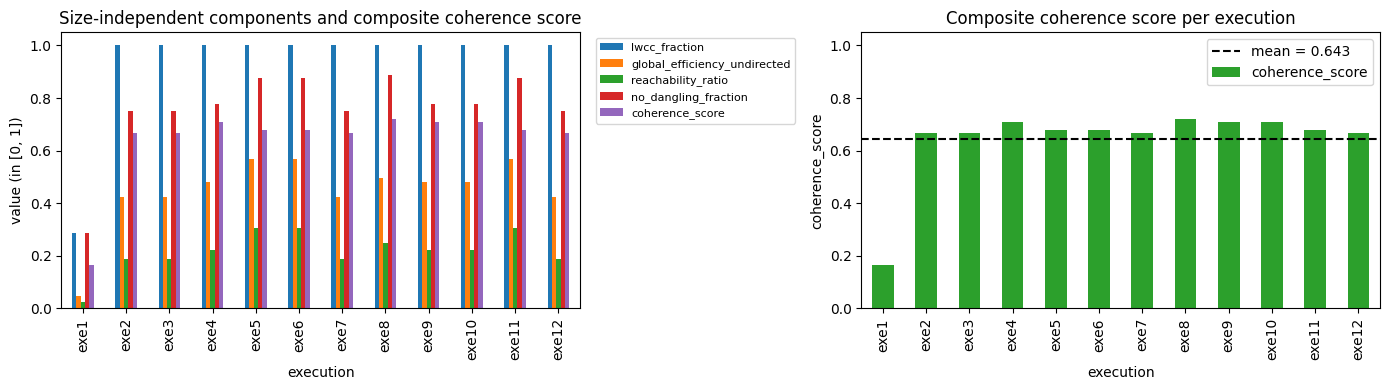

In [13]:
# Composite coherence score + its components across executions.
components = [
    "lwcc_fraction",
    "global_efficiency_undirected",
    "reachability_ratio",
    "no_dangling_fraction",
]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

coherence_df[components + ["coherence_score"]].plot(kind="bar", ax=ax1)
ax1.set_ylabel("value (in [0, 1])")
ax1.set_title("Size-independent components and composite coherence score")
ax1.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
ax1.set_ylim(0, 1.05)

coherence_df["coherence_score"].plot(kind="bar", ax=ax2, color="#2ca02c")
ax2.axhline(coherence_df["coherence_score"].mean(), color="k", linestyle="--",
            label=f"mean = {coherence_df['coherence_score'].mean():.3f}")
ax2.set_ylabel("coherence_score")
ax2.set_title("Composite coherence score per execution")
ax2.legend()
ax2.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

## 4. Correlation of individual metrics with the composite coherence score

The `coherence_score` is a weighted sum of five components, so it is **expected** to correlate strongly with each of its inputs. The more interesting question is whether metrics that were *not* included in the composite (e.g. `von_neumann_entropy`, `degree_assortativity`, `algebraic_connectivity`, `avg_betweenness`, raw step counts) happen to track the composite anyway — that would tell us whether the composite captures a general "coherence axis" of the methodology graph, or whether its signal is orthogonal to the rest of the metric catalogue.

For each numeric metric from Section 2 (raw graph metrics) and Section 3 (size-independent metrics) we scatter-plot the value vs. the `coherence_score` across the nine executions and annotate each panel with the Pearson correlation $r$ and $p$-value. Panels with $|r| \ge 0.5$ are highlighted.

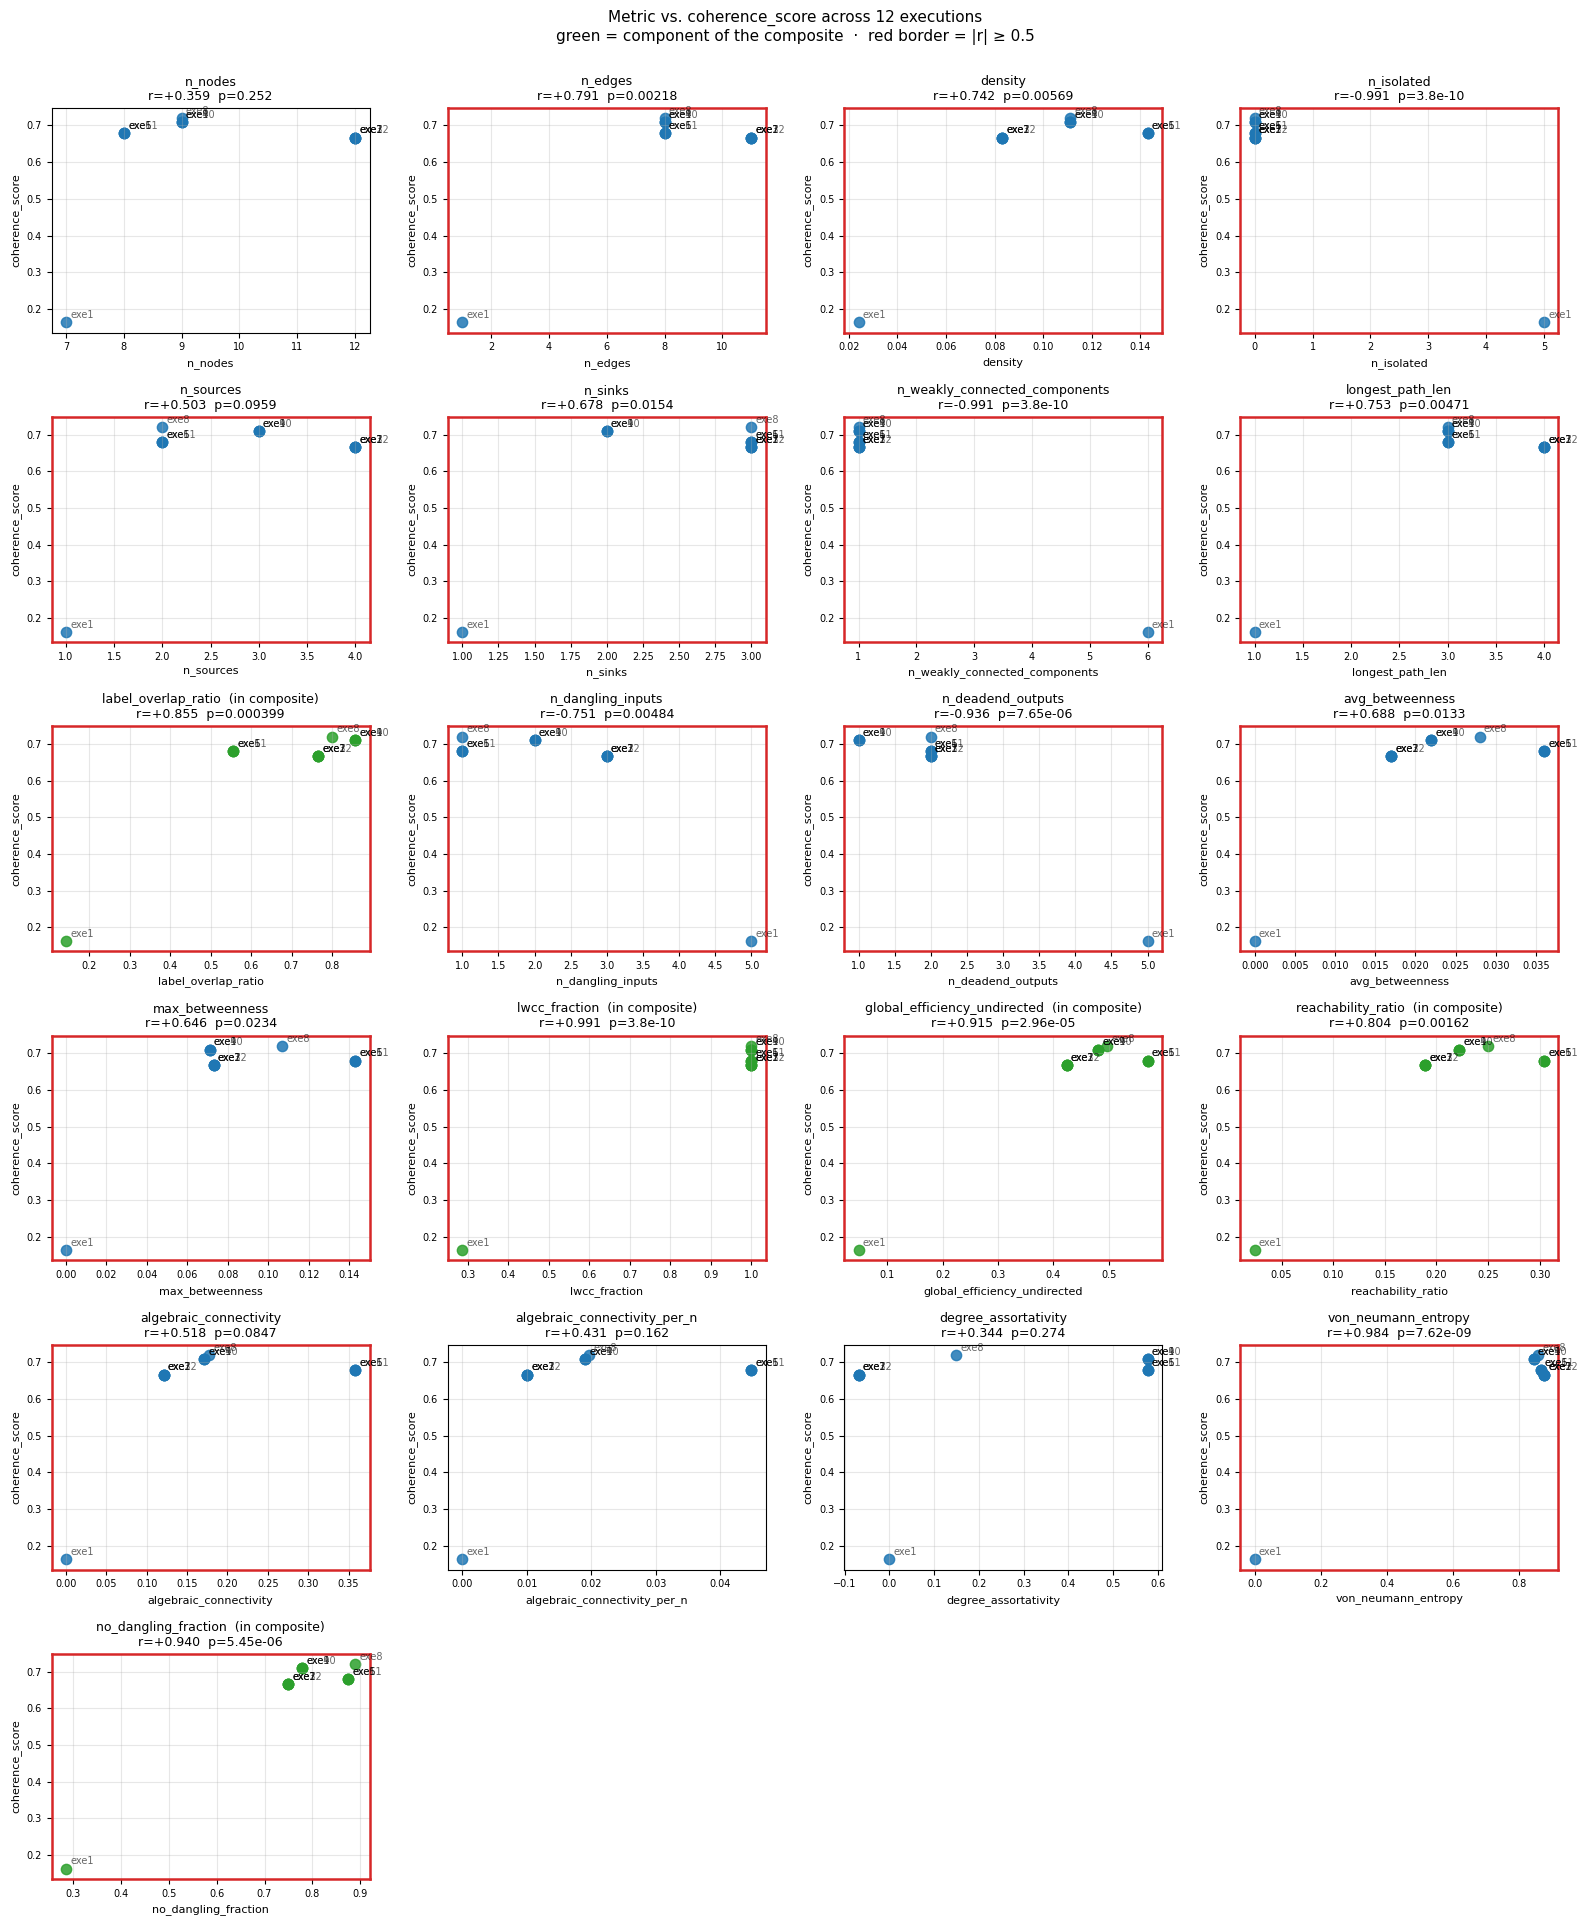

In [14]:
from scipy.stats import pearsonr

# Merge Section 2 + Section 3 numeric metrics into one frame keyed by execution.
merged = (
    metrics_df.select_dtypes(include="number")
    .join(coherence_df.select_dtypes(include="number"), how="inner", rsuffix="_coh")
)

y_col = "coherence_score"
in_composite = {
    "lwcc_fraction",
    "label_overlap_ratio",
    "global_efficiency_undirected",
    "reachability_ratio",
    "no_dangling_fraction",
}

x_cols = [c for c in merged.columns if c != y_col and merged[c].nunique() > 1]

n = len(x_cols)
cols = 4
rows = math.ceil(n / cols)
fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3.2 * rows))
axes = axes.flatten()

y = merged[y_col].to_numpy()
correlations = []
for ax, x_col in zip(axes, x_cols):
    x = merged[x_col].to_numpy()
    try:
        r, p = pearsonr(x, y)
    except Exception:
        r, p = float("nan"), float("nan")
    correlations.append((x_col, r, p))

    ax.scatter(x, y, s=55, alpha=0.85,
               color="#1f77b4" if x_col not in in_composite else "#2ca02c")
    for exe, xv, yv in zip(merged.index, x, y):
        ax.annotate(exe, (xv, yv), fontsize=7, alpha=0.6, xytext=(3, 3),
                    textcoords="offset points")

    if abs(r) >= 0.5:
        for spine in ax.spines.values():
            spine.set_edgecolor("#d62728")
            spine.set_linewidth(1.8)

    in_comp_flag = "  (in composite)" if x_col in in_composite else ""
    ax.set_title(f"{x_col}{in_comp_flag}\nr={r:+.3f}  p={p:.3g}", fontsize=9)
    ax.set_xlabel(x_col, fontsize=8)
    ax.set_ylabel(y_col, fontsize=8)
    ax.tick_params(labelsize=7)
    ax.grid(alpha=0.3)

for ax in axes[n:]:
    ax.axis("off")

plt.suptitle(
    f"Metric vs. {y_col} across {len(merged)} executions\n"
    "green = component of the composite  ·  red border = |r| ≥ 0.5",
    fontsize=11, y=1.00,
)
plt.tight_layout()
plt.show()

In [15]:
# Ranked Pearson correlations with coherence_score.
corr_df = (
    pd.DataFrame(correlations, columns=["metric", "pearson_r", "p_value"])
    .assign(in_composite=lambda d: d["metric"].isin(in_composite))
    .assign(abs_r=lambda d: d["pearson_r"].abs())
    .sort_values("abs_r", ascending=False)
    .drop(columns="abs_r")
    .reset_index(drop=True)
)
corr_df.round(3)

,metric,pearson_r,p_value,in_composite
0,lwcc_fraction,0.991,0.000,True
1,n_weakly_connected_components,-0.991,0.000,False
2,n_isolated,-0.991,0.000,False
3,von_neumann_entropy,0.984,0.000,False
4,no_dangling_fraction,0.940,0.000,True
5,n_deadend_outputs,-0.936,0.000,False
6,global_efficiency_undirected,0.915,0.000,True
7,label_overlap_ratio,0.855,0.000,True
8,reachability_ratio,0.804,0.002,True
9,n_edges,0.791,0.002,False


## 5. Coherence score for a single profile JSON

This section applies the same pipeline (graph construction + size-independent metrics + composite coherence score) to an **arbitrary** `PaperProfile` JSON file — it does not need to be one of the executions loaded in Section 1. Point `JSON_PATH` at any `.profile.json` on disk and re-run the cell.

Uses the functions already defined above: `methodology_graph`, `graph_metrics`, `coherence_metrics`, plus the same composite formula from Section 3.1.

In [16]:
def coherence_from_profile(profile: dict) -> dict:
    """Compute the composite coherence score (and all ingredients) for one profile.

    Accepts a PaperProfile dict (as stored in *.profile.json) and returns:
      - the nx.DiGraph of the methodology,
      - the full metric bundle from Section 2 + Section 3,
      - the composite coherence score computed with the Section 3.1 weights.
    """
    steps = profile.get("methodology_steps", [])
    g = methodology_graph(steps)
    gm = graph_metrics(g, steps)
    cm = coherence_metrics(g)
    n = g.number_of_nodes() or 1
    no_dangling = 1.0 - (gm["n_dangling_inputs"] / n)

    score = (
        0.25 * cm["lwcc_fraction"]
        + 0.25 * gm["label_overlap_ratio"]
        + 0.20 * cm["global_efficiency_undirected"]
        + 0.15 * cm["reachability_ratio"]
        + 0.15 * max(0.0, no_dangling)
    )

    return {
        "graph": g,
        "graph_metrics": gm,
        "coherence_metrics": cm,
        "no_dangling_fraction": round(no_dangling, 3),
        "coherence_score": round(score, 3),
    }


# --- change this path to score any profile on disk ------------------------
JSON_PATH = Path("data/pdf_original_cache/2015_01_article_exe1.profile.json")
# -------------------------------------------------------------------------

assert JSON_PATH.exists(), f"missing: {JSON_PATH}"
profile = json.loads(JSON_PATH.read_text())
result = coherence_from_profile(profile)

print(f"File:     {JSON_PATH.name}")
print(f"Title:    {profile.get('title', '')[:100]}")
print(f"Model:    {profile.get('extraction_model', '')}")
print(f"N steps:  {result['graph'].number_of_nodes()}")
print(f"N edges:  {result['graph'].number_of_edges()}")
print()
print(f"{'COHERENCE SCORE':<32} {result['coherence_score']:>8.3f}   (range 0–1)")
print("-" * 48)
print("Components of the composite:")
print(f"  LWCC fraction           (w=0.25)  {result['coherence_metrics']['lwcc_fraction']:>8.3f}")
print(f"  Label overlap ratio     (w=0.25)  {result['graph_metrics']['label_overlap_ratio']:>8.3f}")
print(f"  Global efficiency (U)   (w=0.20)  {result['coherence_metrics']['global_efficiency_undirected']:>8.3f}")
print(f"  Reachability ratio      (w=0.15)  {result['coherence_metrics']['reachability_ratio']:>8.3f}")
print(f"  No-dangling fraction    (w=0.15)  {result['no_dangling_fraction']:>8.3f}")

File:     2015_01_article_exe1.profile.json
Title:    Interaction between cognitive and motor cortico-basal ganglia loops during decision making: a comput
Model:    gemini-3-flash-preview
N steps:  7
N edges:  8

COHERENCE SCORE                     0.823   (range 0–1)
------------------------------------------------
Components of the composite:
  LWCC fraction           (w=0.25)     1.000
  Label overlap ratio     (w=0.25)     0.875
  Global efficiency (U)   (w=0.20)     0.647
  Reachability ratio      (w=0.15)     0.500
  No-dangling fraction    (w=0.15)     1.000


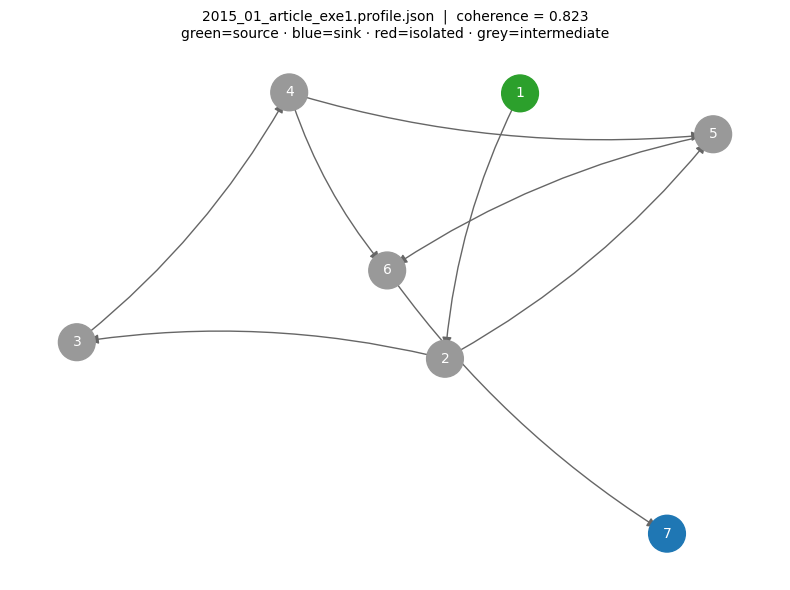

In [17]:
# Visualise the methodology graph for the single profile scored above.
g = result["graph"]
fig, ax = plt.subplots(figsize=(8, 6))

if g.number_of_nodes() == 0:
    ax.text(0.5, 0.5, "empty methodology", ha="center", va="center")
    ax.axis("off")
else:
    pos = nx.spring_layout(g, seed=42, k=1.2)
    node_colors = []
    for v in g.nodes:
        if g.in_degree(v) == 0 and g.out_degree(v) == 0:
            node_colors.append("#d62728")
        elif g.in_degree(v) == 0:
            node_colors.append("#2ca02c")
        elif g.out_degree(v) == 0:
            node_colors.append("#1f77b4")
        else:
            node_colors.append("#999999")
    nx.draw_networkx_nodes(g, pos, ax=ax, node_color=node_colors, node_size=700)
    nx.draw_networkx_labels(g, pos, ax=ax, font_size=10, font_color="white")
    nx.draw_networkx_edges(g, pos, ax=ax, arrows=True, arrowsize=14,
                           connectionstyle="arc3,rad=0.1", edge_color="#666")
    ax.set_title(
        f"{JSON_PATH.name}  |  coherence = {result['coherence_score']:.3f}\n"
        "green=source · blue=sink · red=isolated · grey=intermediate",
        fontsize=10,
    )
    ax.axis("off")

plt.tight_layout()
plt.show()